<a href="https://colab.research.google.com/github/MClem72026/HF-Analytics-Course/blob/main/PythonProject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYPD Arrest Data Analysis Project

# The project will explore NYPD arrest data and compares arrests between all borough and gender. The goal is to identify which borough and gender has the highest number of arrest.  

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

#Check uploaded file

In [27]:
print(os.listdir('/content'))

['.config', 'NYPD.csv', 'sample_data']


#Load dataset
#Preview data

In [23]:
arrests = pd.read_csv('/content/NYPD.csv')
print(arrests.head())

   ARREST_KEY ARREST_DATE  PD_CD                         PD_DESC  KY_CD  \
0   318451126  01/06/2026  105.0               STRANGULATION 1ST  106.0   
1   318308486  01/03/2026  203.0            TRESPASS 3, CRIMINAL  352.0   
2   318550123  01/08/2026  105.0               STRANGULATION 1ST  106.0   
3   318580867  01/07/2026  397.0  ROBBERY,OPEN AREA UNCLASSIFIED  105.0   
4   318684449  01/10/2026  397.0  ROBBERY,OPEN AREA UNCLASSIFIED  105.0   

           OFNS_DESC    LAW_CODE LAW_CAT_CD ARREST_BORO  ARREST_PRECINCT  \
0     FELONY ASSAULT  PL 1211200          F           Q              110   
1  CRIMINAL TRESPASS  PL 140100G          M           K               77   
2     FELONY ASSAULT  PL 1211200          F           B               48   
3            ROBBERY  PL 160102B          F           M               28   
4            ROBBERY  PL 160102A          F           B               45   

   JURISDICTION_CODE AGE_GROUP PERP_SEX       PERP_RACE  X_COORD_CD  \
0                  0 

#View columns

In [3]:
print(arrests.columns)

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')


# Remove rows with missing borough or gender
# count number of arrest by borough
# count number of arrest by gender

In [4]:
arrests_clean = arrests.dropna(subset=['ARREST_BORO', 'PERP_SEX'])
print(arrests_clean["ARREST_BORO"].value_counts())
print(arrests_clean["PERP_SEX"].value_counts())

ARREST_BORO
K    21111
M    15870
B    15613
Q    14160
S     2551
Name: count, dtype: int64
PERP_SEX
M         42719
(null)    16933
F          9653
Name: count, dtype: int64


#Clean gender column by removing and keeping only M and F.
#Observation... after cleaning still see too many nulls. Need one more cleaning step.
#Remove rows where the gender is null.
#Check count again.

In [6]:
arrests_clean = arrests_clean[arrests_clean["PERP_SEX"] != "(null) "]
print(arrests_clean["PERP_SEX"].value_counts())

PERP_SEX
M         42719
(null)    16933
F          9653
Name: count, dtype: int64


#Cleaning code didn't work need something stronger.
#Clean gender by converting to text and removing the spaces
#Keep only M and F Values and check code again.


In [7]:
arrests_clean["PERP_SEX"] = arrests_clean["PERP_SEX"].astype(str).str.strip()
arrests_clean = arrests_clean[arrests_clean["PERP_SEX"].isin(["M", "F"])]
print(arrests_clean["PERP_SEX"].value_counts())

PERP_SEX
M    42719
F     9653
Name: count, dtype: int64


#Create comparison table.

In [8]:
boro_gender = arrests_clean.groupby(['ARREST_BORO', 'PERP_SEX']).size().reset_index(name="Arrest_Count")
print(boro_gender)

  ARREST_BORO PERP_SEX  Arrest_Count
0           B        F          1800
1           B        M          8143
2           K        F          3043
3           K        M         13835
4           M        F          2030
5           M        M          8989
6           Q        F          2296
7           Q        M         10071
8           S        F           484
9           S        M          1681


#Some Descriptive Statistics
#Using Numpy


In [13]:
print(boro_gender["Arrest_Count"].describe())
average_arrests = np.mean(boro_gender["Arrest_Count"])
max_arrests = np.max(boro_gender["Arrest_Count"])
min_arrests = np.min(boro_gender["Arrest_Count"])
print("Average Arrest Count:", average_arrests)
print("Maximum Arrest Count:", max_arrests)
print("Minimum Arrest Count:", min_arrests)

count       10.000000
mean      5237.200000
std       4602.083823
min        484.000000
25%       1857.500000
50%       2669.500000
75%       8777.500000
max      13835.000000
Name: Arrest_Count, dtype: float64
Average Arrest Count: 5237.2
Maximum Arrest Count: 13835
Minimum Arrest Count: 484


In [15]:
borough_names = {"B": "Bronx", "K": "Brooklyn", "Q": "Queens", "M": "Manhattan", "S": "Staten Island"}
boro_gender["ARREST_BORO"] = boro_gender["ARREST_BORO"].replace(borough_names)

#Replace borough codes with the names

#Visualization: Arrest by Borough and Gender

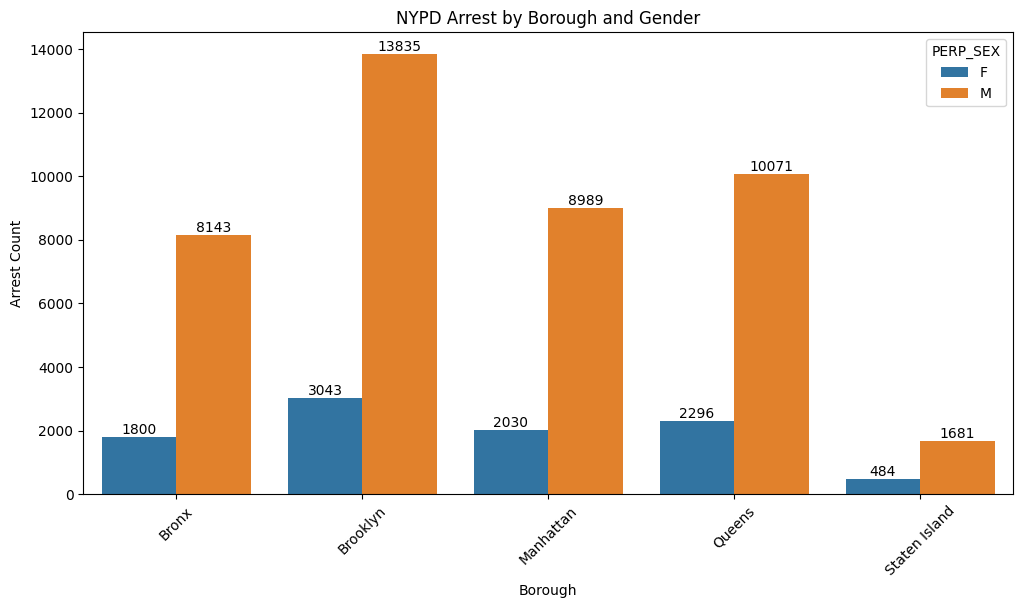

In [22]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=boro_gender, x="ARREST_BORO", y="Arrest_Count", hue="PERP_SEX")
for container in ax.containers:
  ax.bar_label(container)

plt.xticks(rotation=45)
plt.title("NYPD Arrest by Borough and Gender")
plt.xlabel("Borough")
plt.ylabel("Arrest Count")
plt.show()

Observation...Male arrests were significantly higher than female arrests across all boroughs. Brooklyn had the highest overall arrest count, while Staten Island had the lowest. The visualization clearly shows differences in arrest counts by both borough and gender.

Conclusion: This project analyzed NYPD arrest data across New York City boroughs and gender. The analysis showed that male arrest were higher than female arrest across all boroughs. Brooklyn showed the highest overall number of arrests.
